# ***Working with U.S. Census Bureau Data***
**Authored by**: Troyce Mays

**Professor(s)/Supervisor(s)**: Dr. Scott Cook, Dr. Yoa-chi Yu

**Course**: MATH-5365/5366

November 20, 2025

---

# Goals

This seminar notebook seeks to provide general information necessary to understand data from the United States Census Bureau, illustrate common pitfalls that may occur when using census data in python, and provide code to easily produce queries for general census data.

---

# U.S Census Bureau Background

The United States Census Bureau (USCB) has the simple mission of being "the nation's leading provider of quality data about its people and economy", and the USCB seeks to focus on "[providing] the best mix of timeliness, relevancy, quality and cost for the data [they] collect and services [they] provide". The USCB is the largest U.S. government statistical agency and is publicly available while also protecting confidentiality of individuals despite being incredibly easy to acces.

The USCB data is typically accessed from:
- Their main [website](https://data.census.gov/), through either the quick or advanced search features.
- Through URL queries
- Through coding packages (like the one in Python).

When talking about USCB data, it is important to also mention the robustness of the American Community Survey (ACS); more specifically, the ACS 5-year estimates (ACS-5). The ACS-5 is updated yearly, and aggregates data over the last 5 years to give robust data through varying statistical processes in order to create ideal representative variables. Due to how the ACS-5 is compiled and the frequency at which it releases, it is valuable when querying census data for analysis of geology demographics.

The last introductory topic is going to be that of geographical identifiers (GEOIDs). The general diagram for these can be seen below and found through [this link to the hierarchy diagrams for GEOIDs](https://www2.census.gov/geo/pdfs/reference/geodiagram.pdf). Most are generally aware of the common USCB boundaries such as States and Counties; however, the USCB data actually gets more granular than this. USCB data goes into even smaller boundaries in the following order: Census Tracts, Block Groups, and Blocks. Census blocks can actually become even more granular, falling into the categories: Federal American Indian Areas/Off-Reservation Trust Lands, States, and Tribal Designated Statistical Areas.

Regarding the census itself, it is conducted on a decennial (every 10 years) basis. Every decade the census will also update its geographic systems, which can alter GEOIDs in queries. When working with census data, it is important to keep queries and shapefiles within the same decennial census era as your data (when possible).

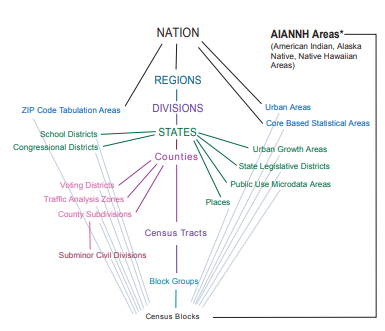

# Coding with the Census Bureau

Coding with the census data follows (roughly) the general diagram:



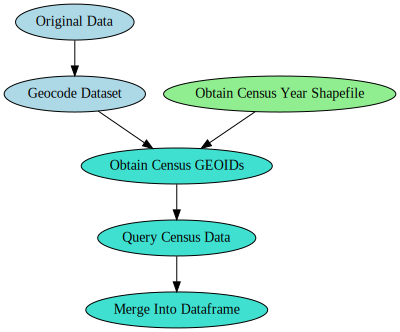

In [1]:
# @title
!pip install graphviz --quiet

from graphviz import Digraph

dot = Digraph()

# Add nodes with fillcolor and style attributes
dot.node('A', 'Original Data', style='filled', fillcolor='lightblue')
dot.node('B', 'Geocode Dataset', style='filled', fillcolor='lightblue')
dot.node('C', 'Obtain Census GEOIDs', style='filled', fillcolor='turquoise')
dot.node('D', 'Obtain Census Year Shapefile', style='filled', fillcolor='lightgreen')
dot.node('E', 'Query Census Data', style='filled', fillcolor='turquoise')
dot.node('F', 'Merge Into Dataframe', style='filled', fillcolor='turquoise')

# Add edges with color attribute
dot.edges(['AB'])
dot.edge('B', 'C',)# label='Merge Using Latitude/Longitude')
dot.edge('D', 'C')
dot.edge('C', 'E')
dot.edge('E', 'F')

# Swap 'LR' to 'TB' for Portrait
dot.attr(rankdir='TB', bgcolor='transparent')
display(dot)

# # Uncomment to save image
# dot.render('Census_Data_Process', format='png', view=True)

In [2]:
## Installations and Imports Needed
# General installation commands
%pip install ipython-autotime --quiet
%load_ext autotime

# Standard imports
import google, numpy as np, sklearn as sk, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
google.colab.drive.mount('/content/drive')

# Geocoding/Census library imports
!pip install geopandas  census  us --quiet
import geopandas as gpd
from shapely.geometry import Point
from census import Census
from us import states

## Define function(s) to quickly get basic df info
# Null value counts
def null_checks(df):
  null_check = df.isnull().sum() > 0
  print("The count of null values currently within the dataset are as follows:\n\n",
    df[null_check[null_check == True].index].isnull().sum(),
    "\n________________________________________________\n")
# Column names, number of rows/columns, and null values counts
def dataset_info(df):
  print("________________________________________________\n")
  print("The column names for the dataset are as follows:\n\n", df.columns,
        "\n________________________________________________\n")
  print("The number of rows and columns in the data frame are:\n", df.shape,
        "\n________________________________________________\n")
  null_checks(df)

  return(display(df.head()),
         print("\n________________________________________________\n"))

###############################################
###############################################
###############################################

## Read in sample dataset
# Importing california housing natively in colab
df = pd.read_csv('/content/sample_data/california_housing_train.csv')
dataset_info(df)
display(df.describe().T)
print("________________________________________________\n")
df.info()
print("________________________________________________\n")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 30.4 MB/s eta 0:00:00
Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 12.0 MB/s eta 0:00:00
________________________________________________

The column names for the dataset are as follows:

 Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object') 
________________________________________________

The number of rows and columns in the data frame are:
 (17000, 9) 
________________________________________________

The count of null values currently within the dataset are as follows:

 Series([], dtype: float64) 
________________________________________________



,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0



________________________________________________



,count,mean,std,min,25%,50%,75%,max
longitude,17000.0,-119.562108,2.005166,-124.3500,-121.790000,-118.4900,-118.000,-114.3100
latitude,17000.0,35.625225,2.137340,32.5400,33.930000,34.2500,37.720,41.9500
housing_median_age,17000.0,28.589353,12.586937,1.0000,18.000000,29.0000,37.000,52.0000
total_rooms,17000.0,2643.664412,2179.947071,2.0000,1462.000000,2127.0000,3151.250,37937.0000
total_bedrooms,17000.0,539.410824,421.499452,1.0000,297.000000,434.0000,648.250,6445.0000
population,17000.0,1429.573941,1147.852959,3.0000,790.000000,1167.0000,1721.000,35682.0000
households,17000.0,501.221941,384.520841,1.0000,282.000000,409.0000,605.250,6082.0000
median_income,17000.0,3.883578,1.908157,0.4999,2.566375,3.5446,4.767,15.0001
median_house_value,17000.0,207300.912353,115983.764387,14999.0000,119400.000000,180400.0000,265000.000,500001.0000


________________________________________________

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB
________________________________________________

time: 34.4 s (started: 2025-11-20 23:46:14 +00:00)


## Geocoding and Census Shapefile

The first step will be to geocode the orginal dataset. This can be done using GeoPandas, which has been shown in class previously. The method done below  essentially creates a geo-dataframe that will act as a temporary dataframe to be altered with census data and eventually merged into the original.

In [3]:
### Obtaining and Merging Shapefile Data to original data
## Create LAT/LONG variables for easier writing
LAT = df['latitude']
LON = df['longitude']

## Create a dataframe of latitude and longitude
geo_points = pd.DataFrame({'LAT': LAT, 'LON': LON})

## Create a GeoDataFrame from geo_points
points_gdf = gpd.GeoDataFrame(
    geo_points,
    geometry = gpd.points_from_xy(
        geo_points.LON,
        geo_points.LAT
    ),
    # Set the Coordinate Reference System (CRS) for consistency
    crs = 'EPSG:4326' # WGS 84 coordinate reference system
)

# Check GeoDataFrame (if desired); needs LAT, LON, and geometry columns
points_gdf.head()

,LAT,LON,geometry
0,34.19,-114.31,POINT (-114.31 34.19)
1,34.40,-114.47,POINT (-114.47 34.4)
2,33.69,-114.56,POINT (-114.56 33.69)
3,33.64,-114.57,POINT (-114.57 33.64)
4,33.57,-114.57,POINT (-114.57 33.57)


time: 81.1 ms (started: 2025-11-20 23:46:48 +00:00)


Before using Census Data, it is important to obtain an appropriate shapefile relative to the geographical area that is being studied. In this case, a shapefile for California is needed. The shapefile is what allows geographic identifiers (GEOIDs) to be identified in order to query information from the census. To have a good balance between geographically specific information and inclusion of general areas, it's recommended to download the "block group" level and move up from there as needed (See [Understanding Geographic Identifiers](https://www.census.gov/programs-surveys/geography/guidance/geo-identifiers.html)).  

In other words, by pairing appropriate Latitude (Lat) and Longitude (Lon) values to a census shapefile it's possible to join key identifying data to a dataset.

Census shapefiles (by year) can be found at the following link: [TIGER/Line Shapefiles](https://www.census.gov/geographies/mapping-files/time-series/geo/tiger-line-file.2024.html#list-tab-790442341). To keep things simple, it is recommended to go through the "Web Interface" option and follow the prompts. For this example, the block groups shapefile for California in 2020 will be used, which falls in the most recently update decade for the census.

In [4]:
'''
  Before running this cell the 'tl_2020_06_bg.shp'
must be in your colab working directory. You will need
to upload the 'tl_2020_06_bg' folder, then call the
file from there.
  Alternatively, use the sharing link at the end of the
notebook to gain access to all files within the notebook
to avoid downloads. Alter file paths as necessary.
'''

###############################################
###############################################
###############################################
## Load in the Census Shapefile
# Change path accordingly
census_blocks_path = '/content/drive/MyDrive/Working_with_Census_Data/tl_2020_06_bg/tl_2020_06_bg.shp'

# Read the file in with GeoPandas
census_bg = gpd.read_file(census_blocks_path)
# Set the CRS on the file to match GeoDataFrame
census_bg = census_bg.set_crs(census_bg.crs) # Set same CRS
census_bg = census_bg.to_crs(points_gdf.crs)


## Perform a join of Census GeoDataFrame and points_gdf
# Using 'within' causes spatial join only if points fall within a shapefile polygon
joined_gdf = gpd.sjoin(
    points_gdf,
    census_bg,
    how = 'left',
    predicate = 'within'
)
# Convert the GDF to a normal pandas df to ensure code compatibility
joined_df = pd.DataFrame(joined_gdf)


## Display Result
joined_df.head()

,LAT,LON,geometry,index_right,STATEFP,COUNTYFP,TRACTCE,BLKGRPCE,GEOID,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON
0,34.19,-114.31,POINT (-114.31 34.19),23061.0,06,071,940100,1,060719401001,Block Group 1,G5030,S,1.125084e+08,2592840.0,+34.1887788,-114.3064842
1,34.40,-114.47,POINT (-114.47 34.4),5800.0,06,071,025100,2,060710251002,Block Group 2,G5030,S,1.866608e+09,42589543.0,+34.3993055,-114.4700616
2,33.69,-114.56,POINT (-114.56 33.69),24833.0,06,065,047000,3,060650470003,Block Group 3,G5030,S,5.722179e+07,1187234.0,+33.6802518,-114.5523997
3,33.64,-114.57,POINT (-114.57 33.64),24833.0,06,065,047000,3,060650470003,Block Group 3,G5030,S,5.722179e+07,1187234.0,+33.6802518,-114.5523997
4,33.57,-114.57,POINT (-114.57 33.57),7027.0,06,065,047000,1,060650470001,Block Group 1,G5030,S,5.683899e+07,1655822.0,+33.5551570,-114.5739344


time: 9.65 s (started: 2025-11-20 23:46:48 +00:00)


In [5]:
### Joining the GEOID information to Original Dataframe
## Create a simple Geoid dataframe, and test it for compatibility
Geoid = joined_df[['LAT', 'LON', 'GEOID']]

# Check if the shapes of the two dataframes are the same
print("\nShape of Geoid DataFrame:", Geoid.shape)
print("Shape of df[['latitude', 'longitude']] DataFrame:", df[['latitude', 'longitude']].shape)

# Check if the 'LAT' and 'LON' columns are identical in both dataframes
lat_match = (Geoid['LAT'] == df['latitude']).all()
lon_match = (Geoid['LON'] == df['longitude']).all()
print("\n'LAT' columns match:", lat_match)
print("'LON' columns match:", lon_match)

# Check if all rows are identical based on LAT and LON
all_rows_match = lat_match and lon_match and (Geoid.shape[0] == df.shape[0])
print("\nAll rows match (based on LAT and LON and shape):", all_rows_match)


## Append GeoID to the df dataframe for later use.
df['GEOID'] = Geoid['GEOID']
# Check general dataframe info
dataset_info(df)


Shape of Geoid DataFrame: (17000, 3)
Shape of df[['latitude', 'longitude']] DataFrame: (17000, 2)

'LAT' columns match: True
'LON' columns match: True

All rows match (based on LAT and LON and shape): True
________________________________________________

The column names for the dataset are as follows:

 Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'GEOID'],
      dtype='object') 
________________________________________________

The number of rows and columns in the data frame are:
 (17000, 10) 
________________________________________________

The count of null values currently within the dataset are as follows:

 GEOID    2
dtype: int64 
________________________________________________



,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,GEOID
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0,060719401001
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0,060710251002
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0,060650470003
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0,060650470003
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0,060650470001



________________________________________________



(None, None)

time: 48.9 ms (started: 2025-11-20 23:46:58 +00:00)


The above GEOID contains 12 characters, which corresponds to the "Block Group" level of the census. This is generally a good level to query census data from, but missing values can occur for GEOID if any LAT/LON points happen to fall on any boundary lines within the shapefile (which can confuse the GEOID query not knowing what to do with multiple cases of this). These errors could typically be solved by:

1. "Jittering" points, which alters LAT/LON values slightly to avoid this issue
    - *Asking an LLM (ChatGPT, Google Gemini, Microsoft Copilot, etc.) about "jittering latitude and longitude in geopandas" should provide necessary insight if large issues with null GEOID values arises*  
1. Going up in the geographic hierarchy, which alters shapefile polygons to  include the points that were previously stuck on boundary lines
    - *Example: Block Groups -> Tracts*
1. Dropping the rows
    - *Please consider if dropping the rows is worth the loss of data before doing so*

From the general dataset info above it can be seen that there are two rows with missing GEOID values. One can quickly reference where these points are by plotting the rows with null GEOID values, and decide if they are worth imputing or attempting to correct from there. *In practice, an interactive map should probably be developed to zoom in and see exactly where points fall if issues occur.*

Matching LAT/LON coordinates from null GEOID rows found in non-null GEOID rows:


,latitude,longitude,GEOID
0,32.54,-117.04,NaN
1,38.96,-119.94,NaN


None
Found 2 rows with null GEOIDs that have matching LAT/LON coordinates in non-null GEOID rows. 
________________________________________________



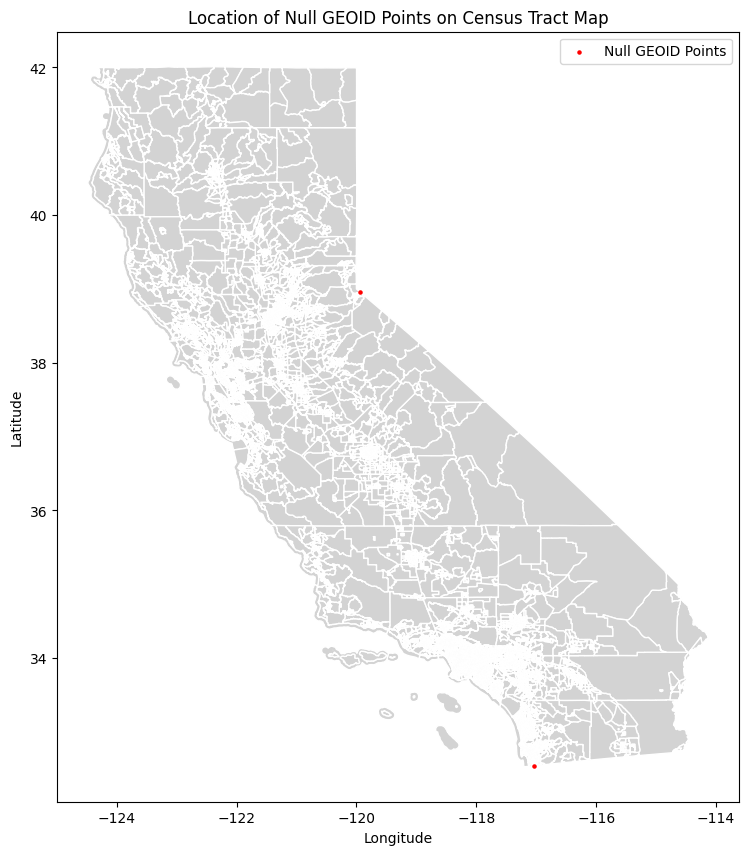

Duplicate points almost fall outside of shapefile and have low count. Dropping the rows: 
________________________________________________

The column names for the dataset are as follows:

 Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'GEOID'],
      dtype='object') 
________________________________________________

The number of rows and columns in the data frame are:
 (16998, 10) 
________________________________________________

The count of null values currently within the dataset are as follows:

 Series([], dtype: float64) 
________________________________________________



,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,GEOID
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0,060719401001
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0,060710251002
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0,060650470003
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0,060650470003
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0,060650470001



________________________________________________



(None, None)

time: 17.2 s (started: 2025-11-20 23:46:58 +00:00)


In [6]:
## Exploring the null GEOID Values
# Find rows with null GEOIDs and select their LAT/LON
null_geoid_coords = df[df['GEOID'].isnull()][['latitude', 'longitude']].copy()

# Find rows with non-null GEOIDs and select LAT/LON and GEOID
non_null_geoid_coords = df[df['GEOID'].notnull()][['latitude', 'longitude', 'GEOID']].copy()

# Merge the two dataframes on LAT and LON seeing if null coords match non-null coords
matched_coords = pd.merge(null_geoid_coords, non_null_geoid_coords, on=['latitude', 'longitude'], how='left')

# Display the results
print("Matching LAT/LON coordinates from null GEOID rows found in non-null GEOID rows:")
print(display(matched_coords))

# Check if any matches were found
if not matched_coords.empty:
    print(f"Found {len(matched_coords)} rows with null GEOIDs that have matching LAT/LON coordinates in non-null GEOID rows.",
          "\n________________________________________________\n")
else:
    print("\nNo matching LAT/LON coordinates from null GEOID rows found in non-null GEOID rows.",
          "\n________________________________________________\n")

###############################################
###############################################
###############################################
### Plotting location of null-GEOID points
# Create a GeoDataFrame for the points with null GEOIDs
null_points_gdf = gpd.GeoDataFrame(
    null_geoid_coords,
    geometry=gpd.points_from_xy(null_geoid_coords.longitude, null_geoid_coords.latitude),
    crs='EPSG:4326' # Set the CRS to match the census shapefile
)

# Ensure the census_gdf is in the same CRS
census_gdf = census_bg.to_crs(null_points_gdf.crs)

## Create the plot
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
# Plot the census tracts
census_gdf.plot(ax=ax, color='lightgray', edgecolor='white')
# Plot the null GEOID points on top
null_points_gdf.plot(ax=ax, marker='o', color='red', markersize=5, label='Null GEOID Points')
# Add title and labels
ax.set_title('Location of Null GEOID Points on Census Tract Map')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
# Add a legend
ax.legend()
# Display the plot
plt.show()
# Optionally save the plot
# plt.savefig('/content/Null_GEOID_Points_on_Map.png', bbox_inches='tight', dpi=300)

print("Duplicate points almost fall outside of shapefile and have low count. Dropping the rows: ")
df = df.dropna(subset=['GEOID'])
dataset_info(df)

## Querying and Merging Census Data

The most recent year for the 5-year estimation through the American Community Survey (ACS) available for query is 2023. This will be the assumed year for all obtained census information. A census API key is needed in order to query census data using the available Python Census API package/wrapper. Information on how to use the wrapper can be found here: [ Documentation for US Census Bureau's API](https://pypi.org/project/census/). Applying for an API key to request data using API can be done with the following link: [Register for Census API key here](https://api.census.gov/data/key_signup.html).

In [7]:
## API Key Setup (replace with unique API key)
c = Census("7c1fdf3bc26d456e9a4167cf545c2677f0e9c5af")

time: 127 ms (started: 2025-11-20 23:47:15 +00:00)


The next topic is how and what do you actually want to query from the census? The following website [acs5year API Gateway](https://proximityone.com/apigateway_acs5year.htm) is a useful tool to answer this question, it explains the construction of Table IDs for the acs5 census format and allows one to `CTRL+F` the site to locate general information. Some general variables are included below:

`"B01001_001E" Total Population (Estimate) `

`"B01002_001E"     Median age, male and female included`

`"B19013_001E"     Median household income in the past 12 months (in 2010 inflation-adjusted dollars)`
- *Inflation adjusted dollars adjusts based on the current ACS-5 year which is defined in query code, the default is 2023*

Some issues can arise from attempting to query Census data in the basic version of colab, it is recommended to be run the notebook on either a TPU setting or a GPU setting to avoid timeout or connection issues due to long query times by utilizing a slightly faster CPU.

---

It is possible to do direct queries from the census without merging anything into a dataframe as desired. There are two examples below; one returns the name of the geographic area and the number of homes that were built before 1939 for the state of Maryland; the other returns the median age for all states in the USCB.

In [8]:
# Set the API key
c

time: 2.29 ms (started: 2025-11-20 23:47:15 +00:00)


In [9]:
# Example from the documentation website
c.acs5.get(('NAME', 'B25034_010E'),
          {'for': 'state:{}'.format(states.MD.fips)})

[{'NAME': 'Maryland', 'B25034_010E': 129256.0, 'state': '24'}]

time: 2.15 s (started: 2025-11-20 23:47:15 +00:00)


In [10]:
'''
Note this cell output also shows state IDs
'''

# Check median age for all states
c.acs5.get(('NAME', 'B01002_001E'),
          {'for': 'state:*'})

[{'NAME': 'Alabama', 'B01002_001E': 39.3, 'state': '01'},
 {'NAME': 'Alaska', 'B01002_001E': 35.6, 'state': '02'},
 {'NAME': 'Arizona', 'B01002_001E': 38.8, 'state': '04'},
 {'NAME': 'Arkansas', 'B01002_001E': 38.4, 'state': '05'},
 {'NAME': 'California', 'B01002_001E': 37.6, 'state': '06'},
 {'NAME': 'Colorado', 'B01002_001E': 37.5, 'state': '08'},
 {'NAME': 'Connecticut', 'B01002_001E': 41.2, 'state': '09'},
 {'NAME': 'Delaware', 'B01002_001E': 41.5, 'state': '10'},
 {'NAME': 'District of Columbia', 'B01002_001E': 34.9, 'state': '11'},
 {'NAME': 'Florida', 'B01002_001E': 42.6, 'state': '12'},
 {'NAME': 'Georgia', 'B01002_001E': 37.4, 'state': '13'},
 {'NAME': 'Hawaii', 'B01002_001E': 40.6, 'state': '15'},
 {'NAME': 'Idaho', 'B01002_001E': 37.1, 'state': '16'},
 {'NAME': 'Illinois', 'B01002_001E': 38.9, 'state': '17'},
 {'NAME': 'Indiana', 'B01002_001E': 38.0, 'state': '18'},
 {'NAME': 'Iowa', 'B01002_001E': 38.6, 'state': '19'},
 {'NAME': 'Kansas', 'B01002_001E': 37.2, 'state': '20'}

time: 776 ms (started: 2025-11-20 23:47:17 +00:00)


Being able to check individual census data is nice, but it would be more useful to actually merge data into our dataframe dependent on the unique GEOIDs we have; which are the final steps of the flow diagram.

To do this, the following steps must occur:
1. Using GEOIDs, extract heirarchical IDs to the desired query point (in this instance it would be Block Groups).
1. Fetch the data up to specified hierarchical level
1. Merge data by row back into the original dataframe

In [11]:
### Cell to merge queries with the overall dataframe
###############################################################################
## Obtain the unique GEOIDs from the DataFrame
unique_geoids = df['GEOID'].dropna().unique()

## Extract state and county FIPS from the first GEOID (assuming all are in the same state/county)
if len(unique_geoids) > 0:
    sample_geoid = unique_geoids[0]
    state_fips = sample_geoid[:2]
    county_fips = sample_geoid[2:5]
    tract_fips = sample_geoid[5:11]
    block_group_fips = sample_geoid[11:]
else:
    state_fips = '06'  # Sets default to California
    county_fips = '037' # Sets default to Los Angeles County
    print("Warning: No valid GEOIDs found in df. Using default state and county FIPS.")


## Fetch data for all tracts in a state/county, then merge dataframes
try:
    # Any desired census variables (2010 website) listed here for query
    variables = ('NAME',
                 'B01003_001E', # Total Population
                 'B01002_001E', # Median Age
                 'B19013_001E', # Median Household Income
                 )
    # Census query
    census_data = c.acs5.state_county_blockgroup(variables, # swap blockgroup for tract if desired
                                           state_fips,
                                           county_fips,
                                           '*', # Use '*' for all Block Groups
                                           year=2023)
    # # Census query
    # census_data = c.acs5.state_county_tract(variables, # swap tract for blockgroup if desired
    #                                        state_fips,
    #                                        county_fips,
    #                                        '*', # Use '*' for all Tracts
    #                                        year=2023)


    # Convert the list of dictionaries to a pandas DataFrame
    census_df = pd.DataFrame(census_data)

    # Build the GEOID for merging in this case:
    # [state + county + tract + block group]
    census_df['GEOID'] = census_df['state'] + census_df['county'] + census_df['tract'] + census_df['block group']

    # Select relevant columns (variables) and merge with original dataframe
    # Keep only the GEOID and the fetched variable for census data merging
    census_cols_to_keep = ['GEOID'] + list(variables)
    census_df_merged = census_df[census_cols_to_keep]

    # Merge with the main DataFrame
    df_with_census = pd.merge(df, census_df_merged, on='GEOID', how='left')

    # Display merged dataframe
    display(df_with_census.head())

except Exception as e:
    print(f"An error occurred while fetching census data: {e}")

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,GEOID,NAME,B01003_001E,B01002_001E,B19013_001E
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0,060719401001,Block Group 1; Census Tract 9401; San Bernardi...,1203.0,64.0,37679.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0,060710251002,Block Group 2; Census Tract 251; San Bernardin...,761.0,55.5,44643.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0,060650470003,NaN,NaN,NaN,NaN
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0,060650470003,NaN,NaN,NaN,NaN
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0,060650470001,NaN,NaN,NaN,NaN


time: 1.74 s (started: 2025-11-20 23:47:18 +00:00)


Unfortunately, the California Housing Dataset is from 1990. This means many GEOID values will not match up due to the nature of when GEOID values are updated (decennial basis) and accessibility to older shapefiles. In the below cell the rows with missing 'NAME' variables are dropped to illustrate what a "successful" query would look like.

In [12]:
df_with_census = df_with_census.dropna(subset=['NAME'])
dataset_info(df_with_census)

________________________________________________

The column names for the dataset are as follows:

 Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'GEOID', 'NAME', 'B01003_001E', 'B01002_001E',
       'B19013_001E'],
      dtype='object') 
________________________________________________

The number of rows and columns in the data frame are:
 (692, 14) 
________________________________________________

The count of null values currently within the dataset are as follows:

 Series([], dtype: float64) 
________________________________________________



,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,GEOID,NAME,B01003_001E,B01002_001E,B19013_001E
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0,060719401001,Block Group 1; Census Tract 9401; San Bernardi...,1203.0,64.0,37679.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0,060710251002,Block Group 2; Census Tract 251; San Bernardin...,761.0,55.5,44643.0
7,-114.59,34.83,41.0,812.0,168.0,375.0,158.0,1.7083,48500.0,060710251002,Block Group 2; Census Tract 251; San Bernardin...,761.0,55.5,44643.0
9,-114.60,34.83,46.0,1497.0,309.0,787.0,271.0,2.1908,48100.0,060710107001,Block Group 1; Census Tract 107; San Bernardin...,1068.0,57.9,-666666666.0
12,-114.61,34.84,48.0,1291.0,248.0,580.0,211.0,2.1571,48600.0,060710107001,Block Group 1; Census Tract 107; San Bernardin...,1068.0,57.9,-666666666.0



________________________________________________



(None, None)

time: 33.7 ms (started: 2025-11-20 23:47:20 +00:00)


With that the flow chart is complete and one could at this point do further EDA and start working towards implementing the features into your model!

Its important to note that some Table IDs are infinitely more complex than others, and it will be important to observe features carefully and do feature engineering where applicable.
- *One issue (which can be seen above) is some census data is protected and will either import as a zero or -6 repeating value to protect indiviuals in low population areas.*

Observe imported census data carefully in case you need to handle further missing values. Census data has some broad variables like shown above, but it can become extremely granular and specific. Make sure the number you import makes sense!

For example:

- Total adults (18+)

- Total Hispanic population

- Total employed females

- Households with children

These often are not single published variables — they must be computed by summing many subcells of a USCB table.

*A more specific example would be "Educational Attainment", which is separated into individual Table ID's for specific age ranges, place of birth, AND each type of educational attainment achieved. Complex feature engineering may be necessary to acquire desired census data.*

## Census Merge Function

The functions in this section will allow one to apply the following:
- Obtain census GEOIDs, then merge into the original dataframe
- Specify Census TableIDs, then query for the data and merge into the original dataframe
  - *Note: This does not remove any missing GEOIDs from the process. These (and further resulting missing/protected census information) would need to be handled as deemed necessary after applying the functions.*

In [13]:
###############################################
## Clear all user-defined variables/dataframes
from IPython import get_ipython
ipython = get_ipython()
if ipython is not None:
    # Delete all user-defined variables
    ipython.magic("reset -f")

print("All user-defined variables and dataframes have been cleared.")

All user-defined variables and dataframes have been cleared.
time: 279 ms (started: 2025-11-20 23:47:20 +00:00)


In [14]:
###############################################
## Installations and Imports Needed
# General installation commands
%pip install ipython-autotime --quiet
%load_ext autotime

# Standard imports
import google, numpy as np, sklearn as sk, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
google.colab.drive.mount('/content/drive')

# Geocoding/Census library imports
!pip install geopandas  census  us --quiet
import geopandas as gpd
from shapely.geometry import Point
from census import Census
from us import states

###############################################
## Define function(s) to quickly get basic df info
# Null value counts
def null_checks(df):
  null_check = df.isnull().sum() > 0
  print("The count of null values currently within the dataset are as follows:\n\n",
    df[null_check[null_check == True].index].isnull().sum(),
    "\n________________________________________________\n")
# Column names, number of rows/columns, and null values counts
def dataset_info(df):
  print("________________________________________________\n")
  print("The column names for the dataset are as follows:\n\n", df.columns,
        "\n________________________________________________\n")
  print("The number of rows and columns in the data frame are:\n", df.shape,
        "\n________________________________________________\n")
  null_checks(df)

  return(display(df.head()),
         print("\n________________________________________________\n"))

###############################################
## Read in sample dataset
# Importing california housing natively in colab
df = pd.read_csv('/content/sample_data/california_housing_train.csv')
df = df.rename(columns={'longitude': 'LON', 'latitude': 'LAT'})
dataset_info(df)
display(df.describe().T)

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
________________________________________________

The column names for the dataset are as follows:

 Index(['LON', 'LAT', 'housing_median_age', 'total_rooms', 'total_bedrooms',
       'population', 'households', 'median_income', 'median_house_value'],
      dtype='object') 
________________________________________________

The number of rows and columns in the data frame are:
 (17000, 9) 
________________________________________________

The count of null values currently within the dataset are as follows:

 Series([], dtype: float64) 
________________________________________________



,LON,LAT,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0



________________________________________________



,count,mean,std,min,25%,50%,75%,max
LON,17000.0,-119.562108,2.005166,-124.3500,-121.790000,-118.4900,-118.000,-114.3100
LAT,17000.0,35.625225,2.137340,32.5400,33.930000,34.2500,37.720,41.9500
housing_median_age,17000.0,28.589353,12.586937,1.0000,18.000000,29.0000,37.000,52.0000
total_rooms,17000.0,2643.664412,2179.947071,2.0000,1462.000000,2127.0000,3151.250,37937.0000
total_bedrooms,17000.0,539.410824,421.499452,1.0000,297.000000,434.0000,648.250,6445.0000
population,17000.0,1429.573941,1147.852959,3.0000,790.000000,1167.0000,1721.000,35682.0000
households,17000.0,501.221941,384.520841,1.0000,282.000000,409.0000,605.250,6082.0000
median_income,17000.0,3.883578,1.908157,0.4999,2.566375,3.5446,4.767,15.0001
median_house_value,17000.0,207300.912353,115983.764387,14999.0000,119400.000000,180400.0000,265000.000,500001.0000


time: 10.5 s (started: 2025-11-20 23:47:20 +00:00)


In [15]:
###############################################
def get_and_merge_census_data(df, census_shape_path, api_key, year=2023):
    """
    Obtains census GEOIDs based on LAT/LON, queries census data, and merges
    it with the original DataFrame.

    Args:
        df: The original pandas DataFrame with 'LAT' and 'LON' columns.
        census_shape_path: Path to the census tract shapefile.
        api_key: Your US Census API key.
        year: The year for the ACS 5-year estimates (default is 2023).

    Returns:
        The original DataFrame with merged census data and the census tract GeoDataFrame.
    """
    # Remove rows with 0 LAT/LON
    df = df[(df['LAT'] != 0) & (df['LON'] != 0)].copy()

    # Create a GeoDataFrame from LAT/LON points
    points_gdf = gpd.GeoDataFrame(
        df[['LAT', 'LON']],
        geometry=gpd.points_from_xy(df.LON, df.LAT),
        crs='EPSG:4326' # WGS 84 coordinate reference system
    )

    # Load and set CRS for the census shapefile
    census_gdf = gpd.read_file(census_shape_path)
    census_gdf = census_gdf.set_crs(census_gdf.crs)
    census_gdf = census_gdf.to_crs(points_gdf.crs)

    # Perform spatial join to get GEOIDs
    joined_gdf = gpd.sjoin(
        points_gdf,
        census_gdf,
        how='left',
        predicate='within'
    )

    # Add GEOID to the original DataFrame
    df['GEOID'] = joined_gdf['GEOID'].values

    # API Key Setup
    c = Census(api_key)

    ## Obtain the unique GEOIDs from the DataFrame
    unique_geoids = df['GEOID'].dropna().unique()

    ## Extract FIPS from a sample GEOID
    if len(unique_geoids) > 0:
        sample_geoid = unique_geoids[0]
        state_fips = sample_geoid[:2]
        county_fips = sample_geoid[2:5]
        tract_fips = sample_geoid[5:11]
        block_group_fips = sample_geoid[11:]
    else:
        state_fips = '06'  # Default to California
        county_fips = '037' # Default to Los Angeles County
        print("Warning: No valid GEOIDs found in df. Using default state and county FIPS.")

###############################################################################
###############################################################################
    #   In the below 'try' statement, please:
    # - Alter desired TableIDs as necessary
    # - Alter census_data to query the desired level
###############################################################################
###############################################################################

    ## Fetch data for all tracts in a state/county
    try:
        variables = ('NAME',
                     'B01001_001E', # Total Population
                     'B01002_001E', # Median Age
                     'B19013_001E', # Median Household Income
                    )

        census_data = c.acs5.state_county_blockgroup(variables,
                                               state_fips,
                                               county_fips,
                                               '*', # All tracts
                                               year=year)

        # Convert to DataFrame and build GEOID for merging
        census_df = pd.DataFrame(census_data)
        census_df['GEOID'] = census_df['state'] + census_df['county'] + census_df['tract'] + census_df['block group']

        # Select relevant columns and merge
        census_cols_to_keep = ['GEOID'] + list(variables)
        census_df_merged = census_df[census_cols_to_keep]

        # Merge with the main DataFrame
        df_with_census = pd.merge(df, census_df_merged, on='GEOID', how='left')

        return df_with_census, census_gdf # Return both the dataframe and the geodataframe

    except Exception as e:
        print(f"An error occurred while fetching census data: {e}")
        return None, None # Return None for both in case of error

time: 2.5 ms (started: 2025-11-20 23:47:31 +00:00)


In [16]:
###############################################
## Applying the census function:
census_shape_path = '/content/drive/MyDrive/Working_with_Census_Data/tl_2020_06_bg/tl_2020_06_bg.shp'
api_key = "7c1fdf3bc26d456e9a4167cf545c2677f0e9c5af" # Replace w/ unique API key
df_with_census, census_gdf = get_and_merge_census_data(df.copy(), census_shape_path, api_key) # Capture both returned values

# Print general dataset info and first 5 rows of the merged data
if df_with_census is not None:
    dataset_info(df_with_census)

# # Display shapefile (optional, uncomment and rename as necessary)
if census_gdf is not None: # Only attempt to plot if census_gdf was successfully returned
    census_gdf.plot()
    plt.title('Census Tracts in California (2020)')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    # # Uncomment to save the shapefile
    # plt.savefig('/content/Census_Shapefile.png', bbox_inches='tight', dpi=300)

________________________________________________

The column names for the dataset are as follows:

 Index(['LON', 'LAT', 'housing_median_age', 'total_rooms', 'total_bedrooms',
       'population', 'households', 'median_income', 'median_house_value',
       'GEOID', 'NAME', 'B01001_001E', 'B01002_001E', 'B19013_001E'],
      dtype='object') 
________________________________________________

The number of rows and columns in the data frame are:
 (17000, 14) 
________________________________________________

The count of null values currently within the dataset are as follows:

 GEOID              2
NAME           16308
B01001_001E    16308
B01002_001E    16308
B19013_001E    16308
dtype: int64 
________________________________________________



,LON,LAT,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,GEOID,NAME,B01001_001E,B01002_001E,B19013_001E
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0,060719401001,Block Group 1; Census Tract 9401; San Bernardi...,1203.0,64.0,37679.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0,060710251002,Block Group 2; Census Tract 251; San Bernardin...,761.0,55.5,44643.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0,060650470003,NaN,NaN,NaN,NaN
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0,060650470003,NaN,NaN,NaN,NaN
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0,060650470001,NaN,NaN,NaN,NaN



________________________________________________

time: 4.91 s (started: 2025-11-20 23:47:31 +00:00)


## References/Useful Links

*Should you wish to directly use files within this notebook instead of downloading from the USCB websites please click the following [folder link](https://drive.google.com/drive/folders/1aQ8NwtnmX0w1Wfh48fPtJVpGbQb_9lo9?usp=sharing) in order to access the folder used within this notebook (note: you will need to change colab file paths).*

---

1. [U.S. Census Bureau Website](https://data.census.gov/)
1. [U.S. Census Bureau: Census API Guide](https://www2.census.gov/data/api-documentation/api-user-guide.pdf): A PDF illustrating how to write USCB queries as URL's and how to export them as csv files if desired, also contains more links and information not specifically mentioned in this notebook. Did not show how to code/query in Python.
1. [U.S. Census Bureau: Guidance for Geography Users](https://www.census.gov/programs-surveys/geography/guidance.html): Landing info page for several useful links below:
    -  [U.S. Census Bureau: TIGER/Line Shapefiles](https://www.census.gov/geographies/mapping-files/time-series/geo/tiger-line-file.2024.html#list-tab-790442341): Link to access web interface for downloading USCB shapefiles by geographic hierarchy.
    - [U.S. Census Bureau: Understanding Geographic Identifiers (GEOIDs)](https://www.census.gov/programs-surveys/geography/guidance/geo-identifiers.html): General source of information for how GEOID's are composed.
    - [U.S. Census Bureau: Hierarchy Diagrams](https://www.census.gov/programs-surveys/geography/guidance/hierarchy.html): Contains more detailed information specifically on the hierarchy of USCB geographic entities.
1. [U.S. Census Bureau: Register for Census API](https://api.census.gov/data/key_signup.html): Link to USCB API registration.
1. [U.S. Census Bureau: Table IDs Explained](https://www.census.gov/programs-surveys/acs/data/data-tables/table-ids-explained.html): Page that explains how USCB TableIDs are composed in more depth.
1. [ProximityOne: ACS-5 Year Estimate Table Items](https://proximityone.com/apigateway_acs5year.htm#acs5popctables): A useful 2010 website for quickly searching for relevant TableIDs to use.
    - [Nicole Paul: Working with American Community Survey (ACS) data in Python](https://nicolepaul.io/post/python-census/): Source where 2010 website was discovered that also has tips and guidance for using Census API.
1. [Census Reporter](https://censusreporter.org/): Website that can help explore USCB data more broadly with keywords. Is more user friendly compared to general USCB Website.
1. [PyPI: Documentation for U.S. Census Bureau's API](https://pypi.org/project/census/): Python documentation for using USCB data in Python.

In [17]:
# Original California Housing Dataset Reference:
from sklearn.datasets import fetch_california_housing
california_housing = fetch_california_housing(as_frame=True)
print(california_housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce